# Lab: Multiple Linear Regression with scikit-learn
In the [theory notes](./05_multiple_linear_regression_theory.md), we learned how Multiple Linear Regression extends Simple Linear Regression to use **two or more features** to predict a continuous target. In the [implementation file](./06_multiple_linear_regression_implementation.py), we built it from scratch using NumPy — both using gradient descent and the normal equation.

**Now let's see how it's done in practice with scikit-learn.** In the [previous lab](./04_simple_linear_regression_lab.ipynb), we used only TV spend to predict sales. This time, we'll incorporate all three advertising channels. In this lab, we will learn how to:

1.  Load and prepare a multi-feature dataset for modeling.
2.  Explore the data to understand each feature and the relationships between them.
3.  Build a Multiple Linear Regression model using **scikit-learn**.
4.  Interpret the model's coefficients for each feature.
5.  Use the model to make predictions.
6.  Visualize predicted vs actual values.

---

## 1. The Dataset

We'll continue with the **Advertising** dataset from the previous lab. It contains data from 200 different markets, showing spending on TV, Radio, and Newspaper ads, alongside resulting Sales. This time, we'll use **all three channels** as features.

Let's start by importing our libraries and loading the data.

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [9]:
# Load the data
data = pd.read_csv("../data/raw/advertising.csv")

# Take a look at the first 5 rows
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [10]:
# Display general information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


Good — 200 rows, no missing values, and all numerical columns. Let's keep only the columns we need.

---

## 2. Preparing the Data

In [11]:
# Keep only the columns we need
sales_df = data[["TV", "Radio", "Newspaper", "Sales"]].copy()

# Convert column names to lower case for consistency
sales_df.columns = [col.lower() for col in sales_df.columns]

# Quick sanity checks
print(f"Shape: {sales_df.shape}")
print(f"Duplicated rows: {sales_df.duplicated().sum()}")
print(f"Missing values:\n{sales_df.isnull().sum()}")

Shape: (200, 4)
Duplicated rows: 0
Missing values:
tv           0
radio        0
newspaper    0
sales        0
dtype: int64


No duplicates, no missing values — the data is clean and ready to explore.

---

## 3. Exploring the Data

Before we build a model, let's explore the data to understand each feature and its relationship with Sales. With multiple features, we want to answer two key questions:

1.  **Which features look like strong predictors of Sales?**
2.  **Are any features highly correlated with *each other*?** (This is called **multicollinearity**, which we discussed in the theory notes.)

### 3.1. Descriptive Statistics

In [12]:
# Descriptive statistics
sales_df.describe()

,tv,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Notice the very different scales: TV spend ranges up to ~296k while Radio and Newspaper are much smaller. This is important context for interpreting the coefficients later.

### 3.2. Distribution of Each Variable

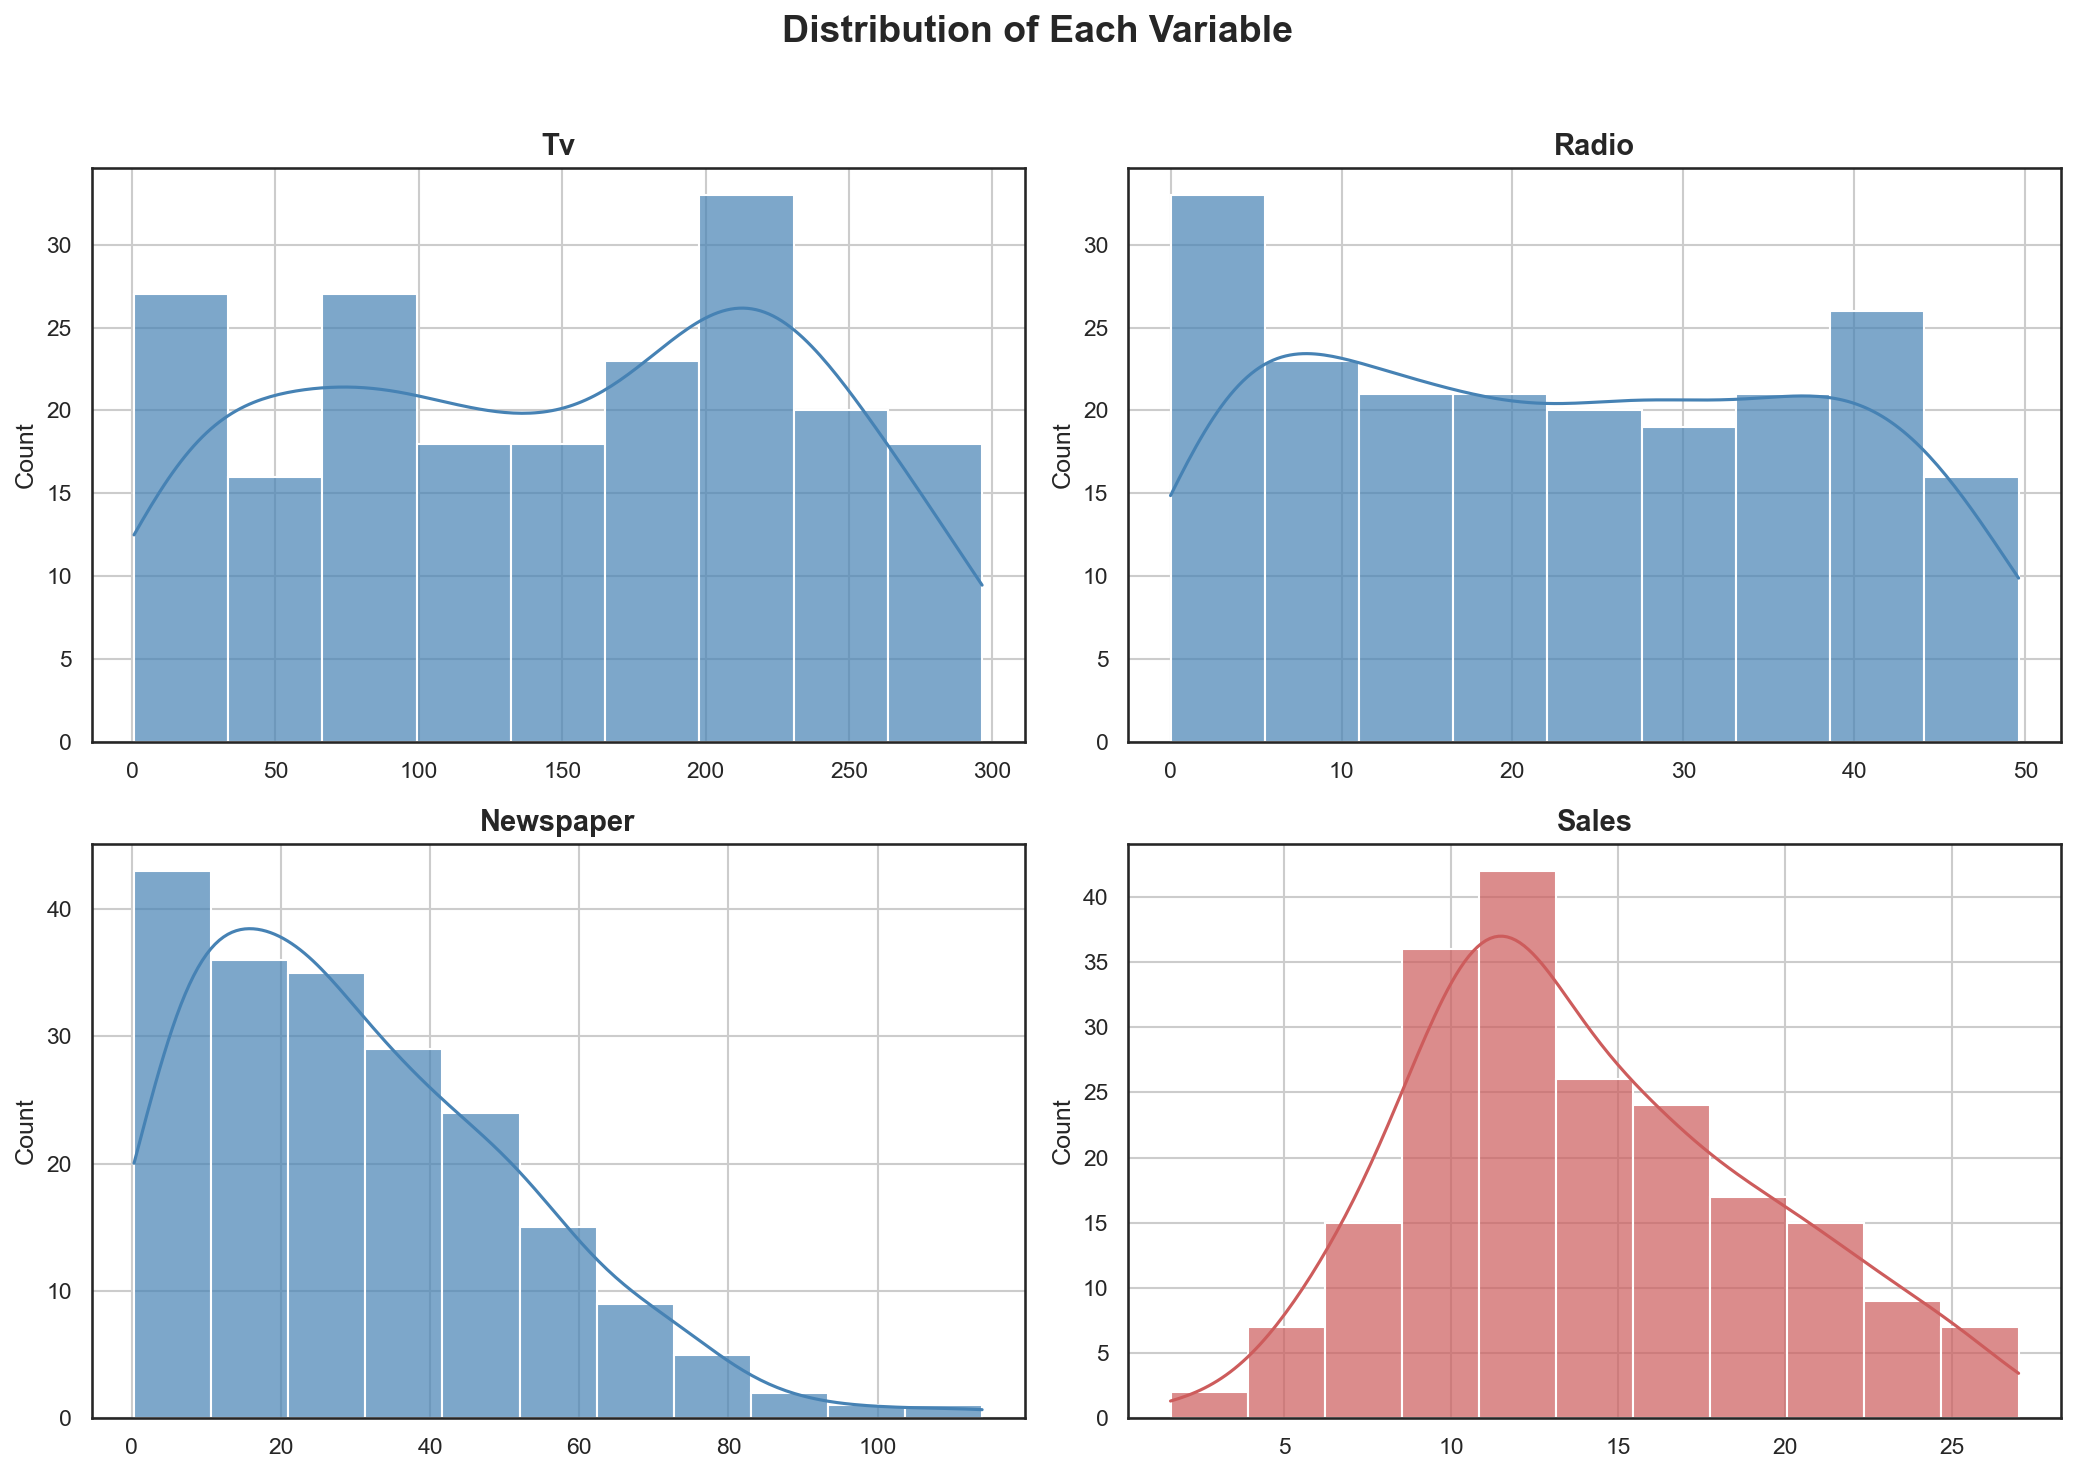

In [13]:
# Histograms of all variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Each Variable", fontsize=18, fontweight='bold')

for ax, col, color in zip(axes.flat,
                           ["tv", "radio", "newspaper", "sales"],
                           ["steelblue", "steelblue", "steelblue", "indianred"]):
    sns.histplot(sales_df, x=col, kde=True, ax=ax, color=color, alpha=0.7)
    ax.set_title(col.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

- **TV** and **Radio** are roughly symmetrically distributed.
- **Newspaper** is right-skewed — a few markets spend a lot more than the rest.
- **Sales** is slightly right-skewed but overall fairly well behaved.

### 3.3. Correlation Analysis

This is a critical step for multiple regression. Let's check the correlations.

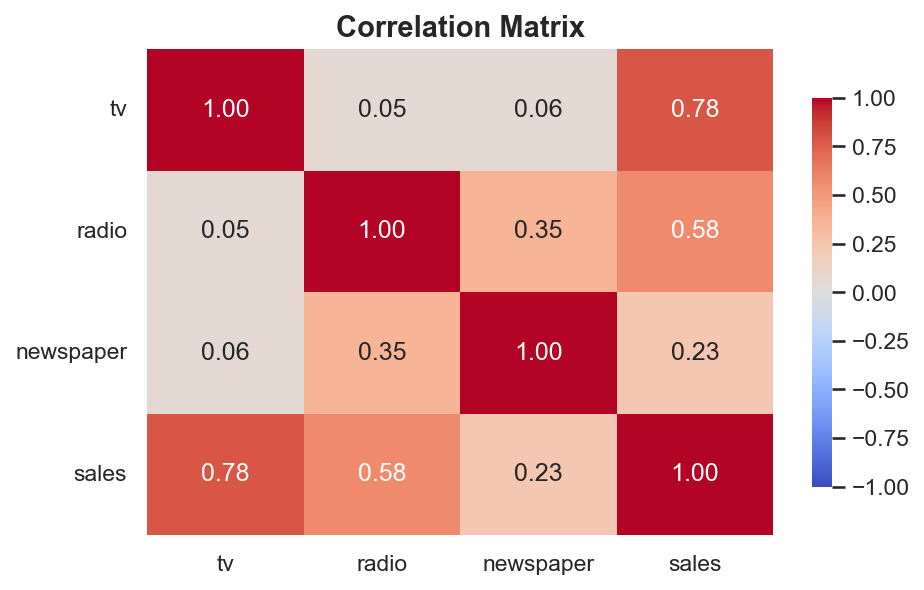

In [14]:
# Correlation matrix
corr_matrix = sales_df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

#### 📌 Key Findings
- **TV → Sales** has the strongest correlation (~0.78) — our best predictor.
- **Radio → Sales** has a moderate correlation (~0.58) — also a useful predictor.
- **Newspaper → Sales** has a weak correlation (~0.23) — unlikely to add much value.
- **Inter-feature correlations are low** — this is good news! Low multicollinearity means the model can cleanly separate the effect of each feature.

### 3.4. Scatter Plots Against Sales

Let's visualize these relationships directly.

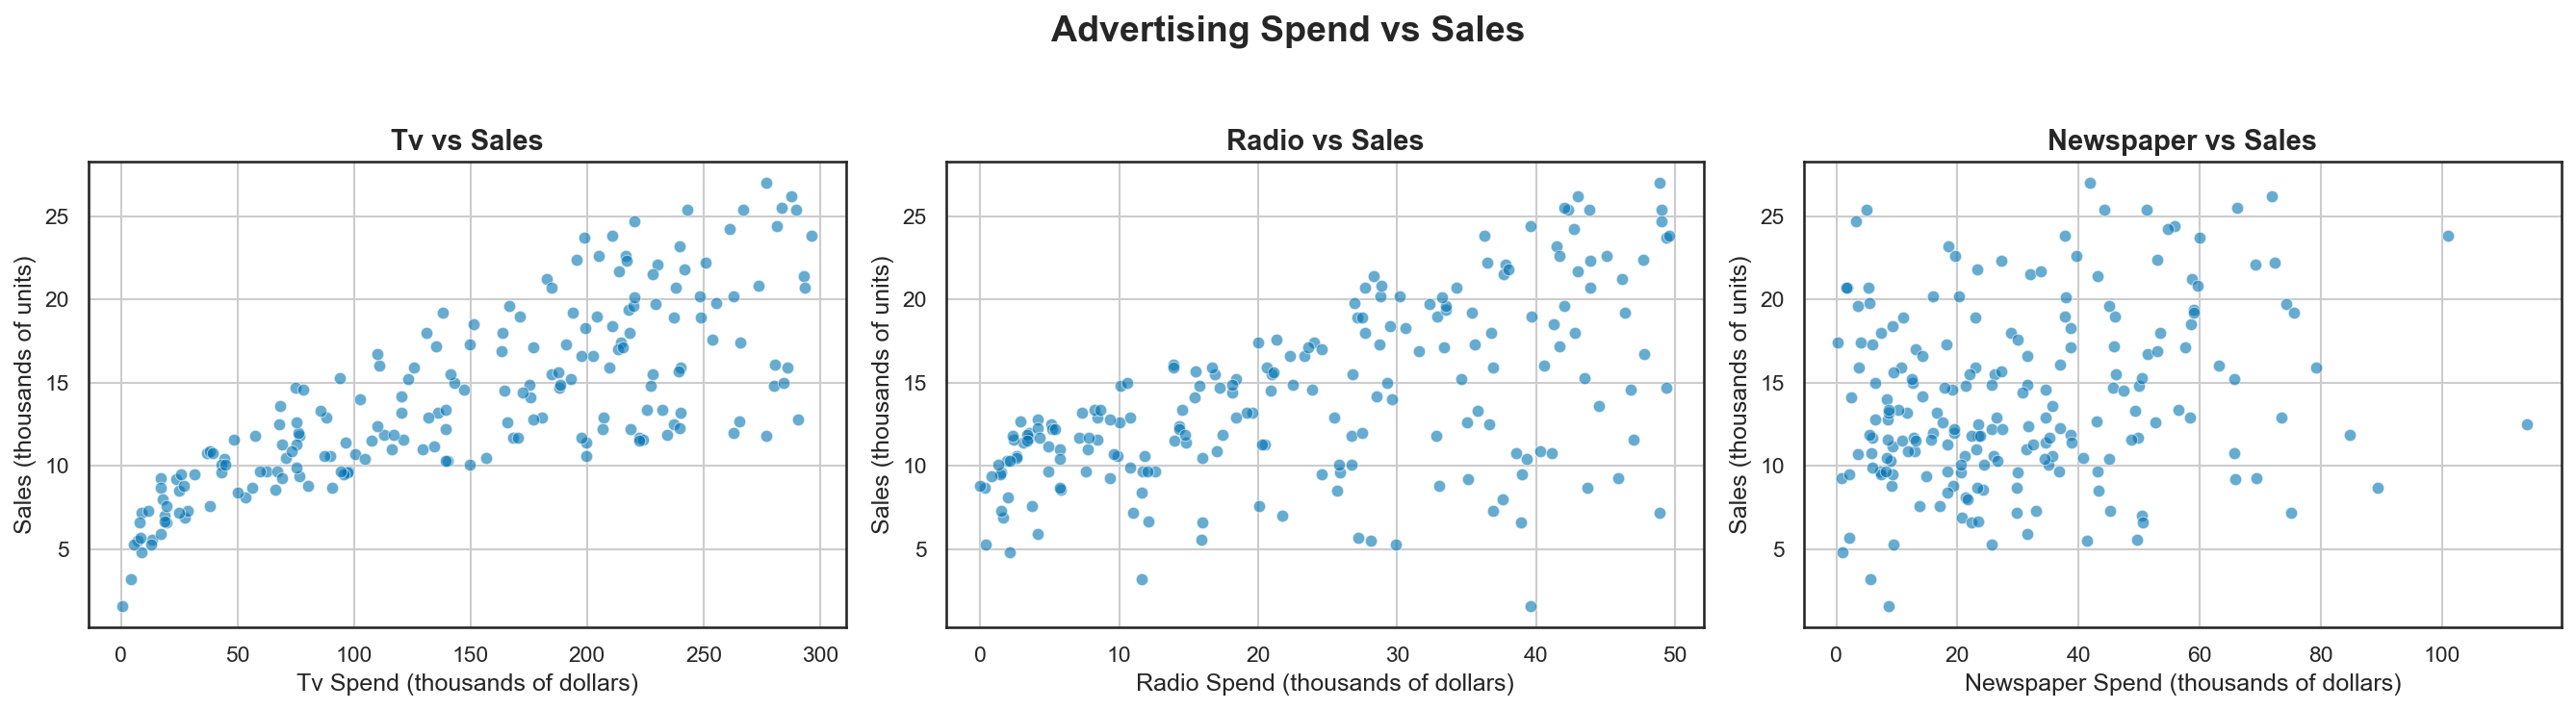

In [15]:
# Scatter plots of each feature vs Sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Advertising Spend vs Sales", fontsize=18, fontweight='bold')

for ax, col in zip(axes, ["tv", "radio", "newspaper"]):
    sns.scatterplot(data=sales_df, x=col, y="sales", ax=ax, alpha=0.6)
    ax.set_title(f"{col.capitalize()} vs Sales", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"{col.capitalize()} Spend (thousands of dollars)", fontsize=12)
    ax.set_ylabel("Sales (thousands of units)", fontsize=12)
    ax.grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

The scatter plots confirm what the correlation matrix told us:
- **TV** shows a clear upward trend.
- **Radio** shows a moderate upward trend.
- **Newspaper** looks almost like a random scatter — no clear linear pattern.

Despite this, we'll include all three features in the model and let the coefficients tell us the story. This is one of the strengths of multiple regression — it can determine the **independent contribution** of each feature while controlling for the others.

---

## 4. Building the Model with scikit-learn

The workflow is the same as simple linear regression, just with more columns in `X`.

### 4.1. Preparing X and y

In [16]:
# Feature matrix — all three advertising channels
X = sales_df[["tv", "radio", "newspaper"]]

# Target vector
y = sales_df["sales"]

print(f"X shape: {X.shape}")  # Expected: (200, 3)
print(f"y shape: {y.shape}")  # Expected: (200,)

X shape: (200, 3)
y shape: (200,)


### 4.2. Creating and Fitting the Model

In [17]:
# Create the model
model = LinearRegression()

# Train the model on the entire dataset
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


### 4.3. Inspecting the Learned Parameters

Recall from the theory that the multiple linear regression equation is:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3$$

The model has now learned a coefficient for **each** feature, plus an intercept. Let's inspect them:

In [18]:
# Build a DataFrame of features and their coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df.to_string(index=False))
print(f"\nIntercept (θ₀): {model.intercept_:.4f}")

  Feature  Coefficient
       tv     0.045765
    radio     0.188530
newspaper    -0.001037

Intercept (θ₀): 2.9389


#### 📌 Interpreting the Coefficients

Each coefficient tells us: *"For every additional $1,000 spent on this channel, how much do predicted sales change — **holding all other channels constant**?"*

This "holding all other channels constant" part is the key difference from simple linear regression. Let's print the interpretation dynamically:

In [19]:
# Print the full model equation with the actual learned values
print(f"Our model equation:")
print(f"  Sales = {model.intercept_:.4f}"
      f" + {model.coef_[0]:.4f} × TV"
      f" + {model.coef_[1]:.4f} × Radio"
      f" + {model.coef_[2]:.4f} × Newspaper")
print()

for feature, coef in zip(X.columns, model.coef_):
    direction = "increase" if coef > 0 else "decrease"
    print(f"{feature.capitalize()} (coefficient = {coef:.4f}):")
    print(f"  → For every additional $1,000 spent on {feature.capitalize()} ads,")
    print(f"    predicted sales {direction} by about {abs(coef) * 1000:,.1f} units")
    print(f"    (holding all other channels constant).")
    print()

Our model equation:
  Sales = 2.9389 + 0.0458 × TV + 0.1885 × Radio + -0.0010 × Newspaper

Tv (coefficient = 0.0458):
  → For every additional $1,000 spent on Tv ads,
    predicted sales increase by about 45.8 units
    (holding all other channels constant).

Radio (coefficient = 0.1885):
  → For every additional $1,000 spent on Radio ads,
    predicted sales increase by about 188.5 units
    (holding all other channels constant).

Newspaper (coefficient = -0.0010):
  → For every additional $1,000 spent on Newspaper ads,
    predicted sales decrease by about 1.0 units
    (holding all other channels constant).



Notice how **Radio** has the largest per-dollar impact on sales, even though TV has the highest overall correlation. This is because the model isolates each feature's *independent* effect. **Newspaper's** coefficient is near zero, confirming it has almost no independent impact on sales once TV and Radio are accounted for.

Let's also visualize the relative magnitude of the coefficients:

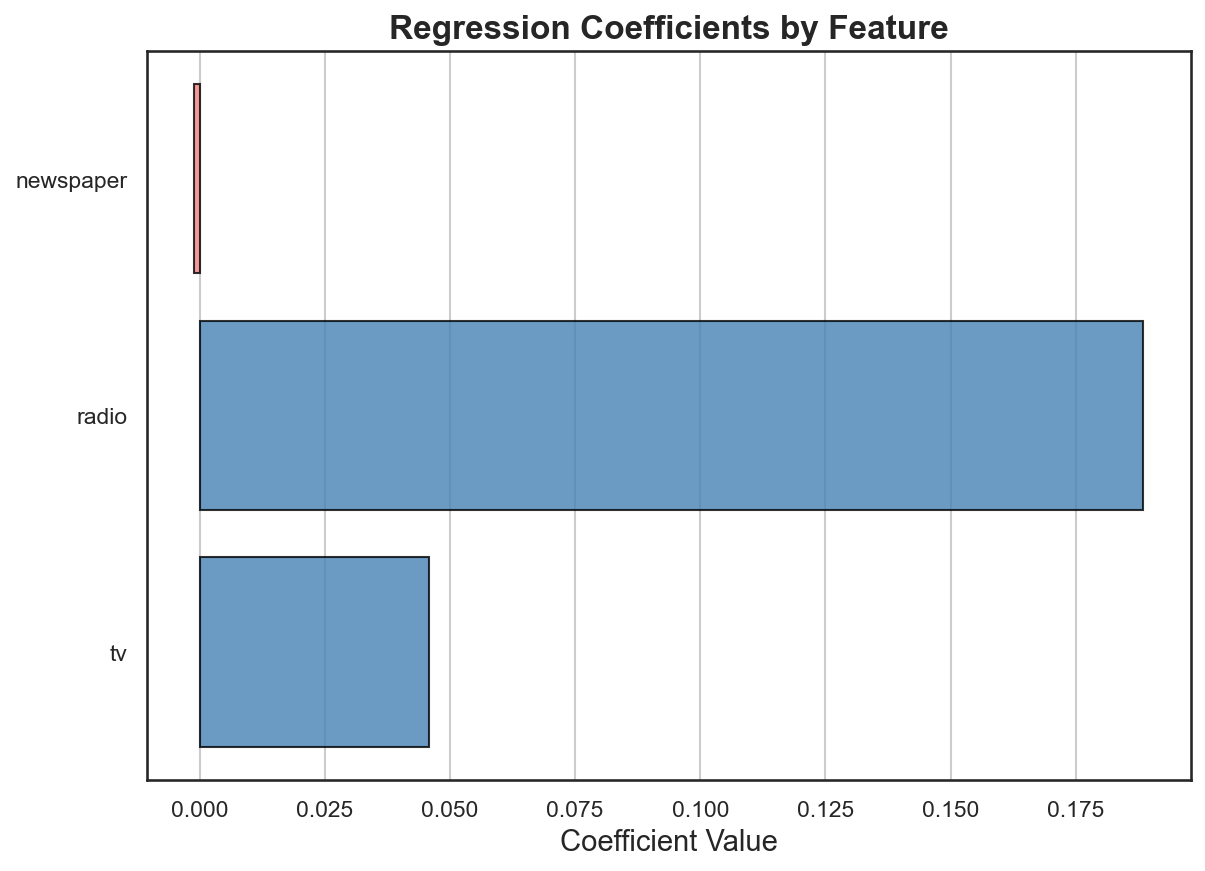

In [20]:
# Bar chart of coefficients
plt.figure()
colors = ["steelblue" if c > 0.01 else "lightcoral" for c in model.coef_]
plt.barh(X.columns, model.coef_, color=colors, edgecolor="black", alpha=0.8)
plt.title("Regression Coefficients by Feature", fontsize=16, fontweight='bold')
plt.xlabel("Coefficient Value", fontsize=14)
plt.grid(axis="x")
plt.show()

---

## 5. Making Predictions

Let's use the model to predict sales for some hypothetical advertising budgets.

In [21]:
# Predict sales for some hypothetical budgets
new_budgets = pd.DataFrame({
    "tv":        [100, 200, 50, 300],
    "radio":     [20,  10,  40,  40],
    "newspaper": [30,  30,  30,  30]
})

predictions = model.predict(new_budgets)

result = new_budgets.copy()
result["predicted_sales"] = np.round(predictions, 2)
print(result.to_string(index=False))

 tv  radio  newspaper  predicted_sales
100     20         30            11.25
200     10         30            13.95
 50     40         30            12.74
300     40         30            24.18


Notice how markets with higher Radio spend (rows 3 and 4) get a noticeable boost in predicted sales, consistent with Radio's strong coefficient.

---

## 6. Visualizing Predicted vs Actual Values

With multiple features, we can't simply draw a regression line on a 2D scatter plot — our model lives in 4-dimensional space! Instead, a common visualization is to plot **predicted values vs actual values**. If the model is perfect, all points would lie on the diagonal line.

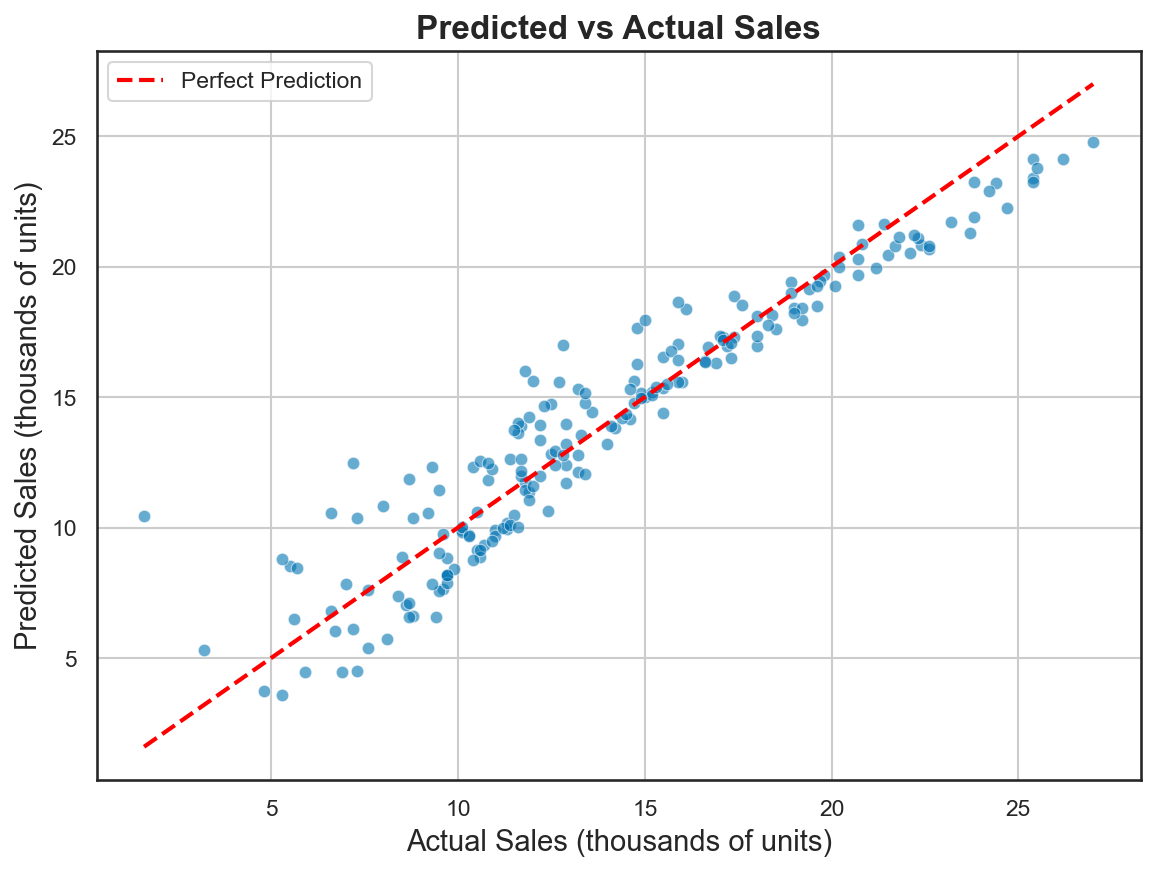

In [22]:
# Predict on the training data
y_pred = model.predict(X)

# Plot predicted vs actual
plt.figure()
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
# Draw the perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red',
         linewidth=2, linestyle='--', label='Perfect Prediction')
plt.title("Predicted vs Actual Sales", fontsize=16, fontweight='bold')
plt.xlabel("Actual Sales (thousands of units)", fontsize=14)
plt.ylabel("Predicted Sales (thousands of units)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

The points cluster closely around the diagonal, which is a good sign. There is some spread — especially at higher sales values — but overall the model captures the trend well.

---

## 7. Comparing Simple vs Multiple Regression

In the previous lab, we used only TV to predict Sales. Let's quickly see the difference that adding Radio and Newspaper makes.

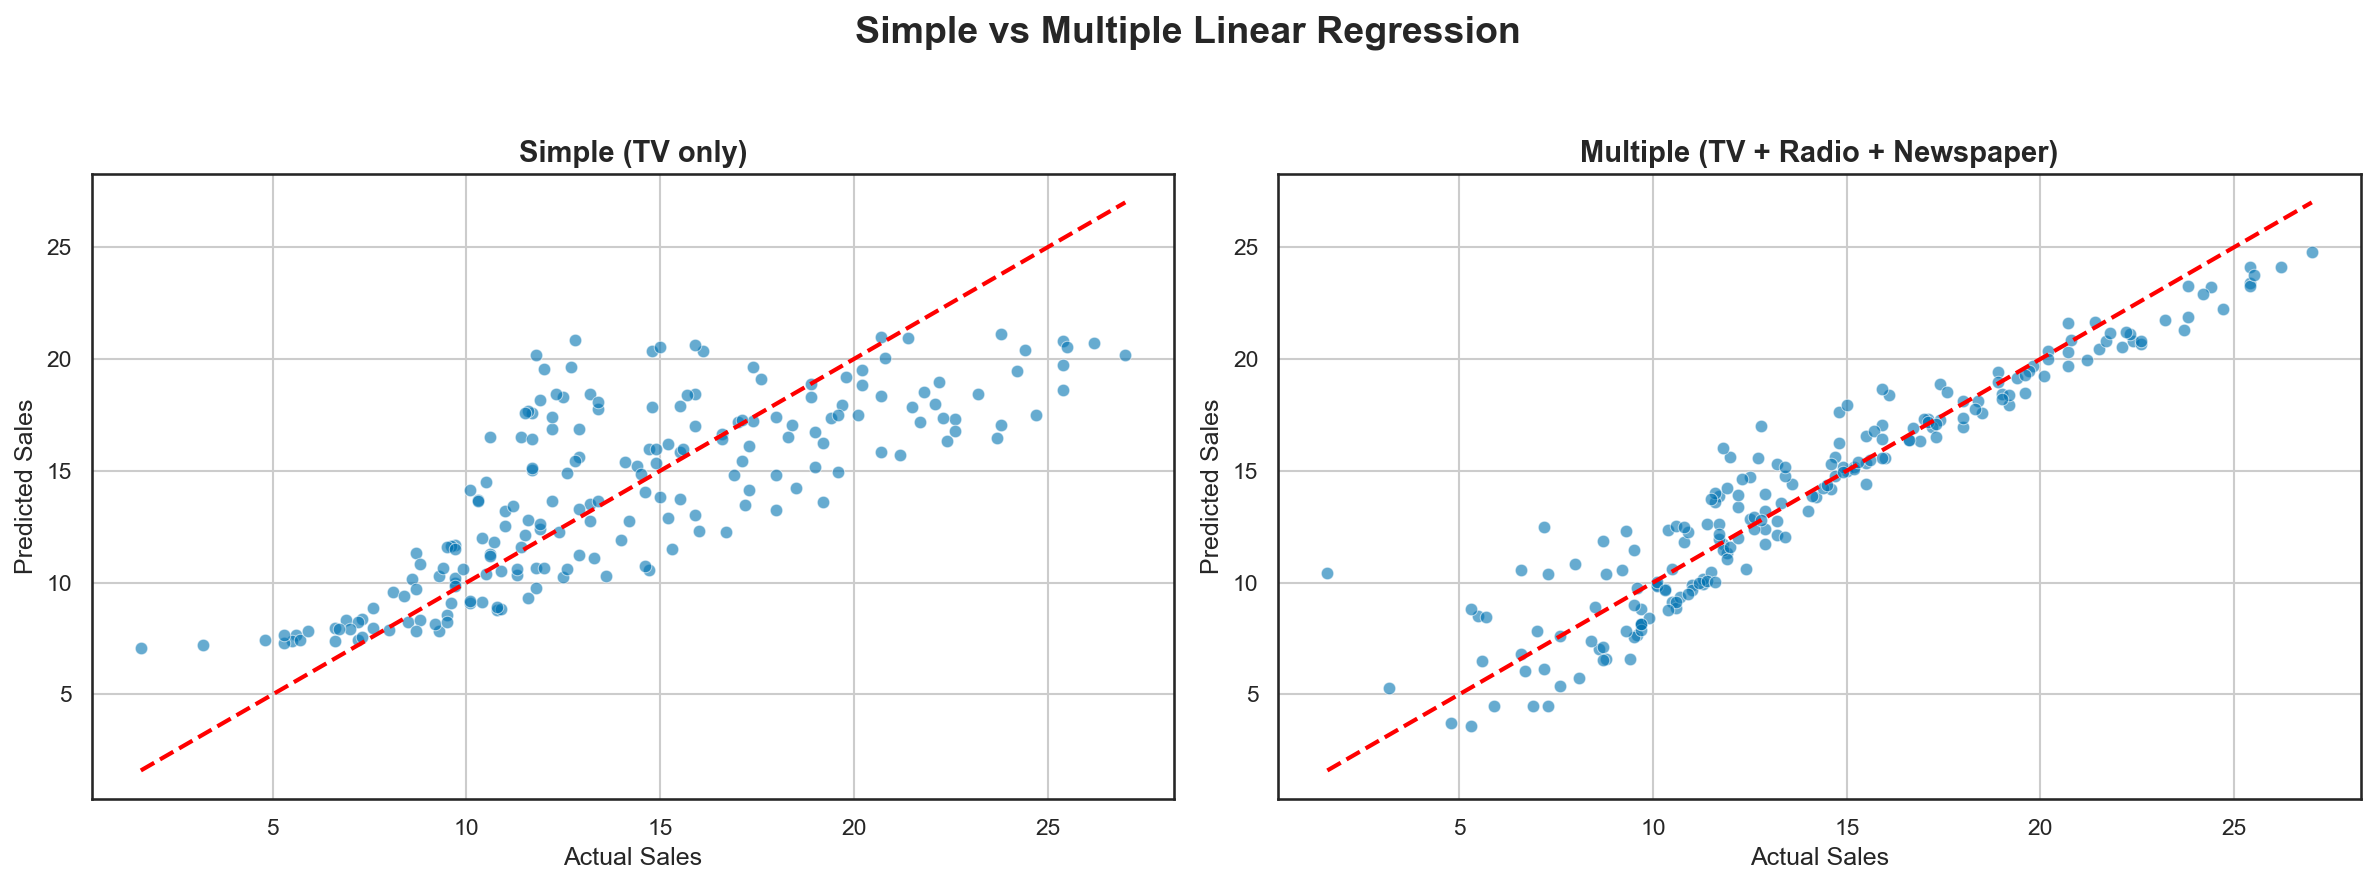

In [23]:
# Build a simple linear regression model using only TV
simple_model = LinearRegression().fit(sales_df[["tv"]], y)
y_pred_simple = simple_model.predict(sales_df[["tv"]])

# Compare the two models side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Simple vs Multiple Linear Regression", fontsize=18, fontweight='bold')

# Simple model
sns.scatterplot(x=y, y=y_pred_simple, alpha=0.6, ax=axes[0])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red',
             linewidth=2, linestyle='--')
axes[0].set_title("Simple (TV only)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Actual Sales", fontsize=12)
axes[0].set_ylabel("Predicted Sales", fontsize=12)
axes[0].grid(True)

# Multiple model
sns.scatterplot(x=y, y=y_pred, alpha=0.6, ax=axes[1])
axes[1].plot([min_val, max_val], [min_val, max_val], color='red',
             linewidth=2, linestyle='--')
axes[1].set_title("Multiple (TV + Radio + Newspaper)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Actual Sales", fontsize=12)
axes[1].set_ylabel("Predicted Sales", fontsize=12)
axes[1].grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

The multiple regression predictions are noticeably tighter around the diagonal. By including Radio (and to a lesser extent Newspaper), the model captures variance in Sales that TV alone couldn't explain.

---

## Summary

In this lab, we extended our scikit-learn skills from simple to multiple linear regression. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Prepare data | Separated multi-feature `X` and target `y` | — |
| Explore data | Checked correlations, distributions, scatter plots | — |
| Create model | Instantiated a `LinearRegression` object | `LinearRegression()` |
| Train model | Fit the model to the data | `model.fit(X, y)` |
| Inspect parameters | Read intercept and per-feature coefficients | `model.intercept_`, `model.coef_` |
| Predict | Used the model to predict new values | `model.predict(X_new)` |

Key takeaways:
- **Radio** has the strongest per-dollar impact on Sales.
- **TV** also contributes meaningfully.
- **Newspaper** adds almost nothing once TV and Radio are in the model.
- Multiple regression lets us isolate each feature's **independent** contribution — a major advantage over simple regression.

---

**Next:** [Logistic Regression Theory](./08_logistic_regression_theory.md)